<a href="https://colab.research.google.com/github/jhonegonzalezq/opti-bio/blob/main/entregableDOCTORADO1403400.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Instalación de librerias**

In [1]:

!pip install bertopic
!pip install sentence-transformers
!pip install umap-learn
!pip install hdbscan
!pip install nltk
!pip install spacy
!pip install bibtexparser
!pip install scikit-learn
!pip install pybibx
!pip install tabulate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=163e6fe555750b064a86a9d12c818804b0244b8411ba8191c340473261725e30
  Stored in directory: /root/.cache/pip/wheels/54/f8/e6/ecfceb6af875ddc5096bb3811795ac336f50371009a601454d
Successfully built bibtexparser
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import textwrap
import bibtexparser
import re
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import data_table
from tabulate import tabulate
from prettytable import PrettyTable
from pybibx.base import pbx_probe

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# **Cargue de documentos**

In [3]:
# Arguments: file_bib = 'filename.bib'; db = 'scopus', 'wos', 'pubmed'; del_duplicated = True, False
file_name = 'scopus1403400.bib'
database  = 'scopus'
bibfile   = pbx_probe(file_bib = file_name, db = database, del_duplicated = True)

A Total of 400 Documents were Found ( 400 Documents and 0 Duplicates )

Article = 400


# **Análisis exploratorio de datos**

In [4]:
# Health Analysis
health = bibfile.health_bib()

# Check Health
health

,Entries,Completeness (%),Number of Docs
0,Sources,100.00%,400
1,Abstracts,99.75%,399
2,Affiliation,100.00%,400
3,Author(s),100.00%,400
4,DOI,100.00%,400
5,Keywords - Authors,96.00%,384
6,Keywords - Plus,78.75%,315
7,References,0.00%,0
8,Year,100.00%,400


In [5]:
# Generate EDA (Exploratory Data Analysis) Report
report  = bibfile.eda_bib()

# Check Report
report

,Main Information,Results
0,Timespan,2020-2026
1,Total Number of Countries,74
2,Total Number of Institutions,568
3,Total Number of Sources,174
4,Total Number of References,0
5,Total Number of Languages,1
6,--english (# of docs),400
7,-//-,-//-
8,Total Number of Documents,400
9,--Article,400


In [6]:
# The metadata can be reviewed and manually modified. If you need to make adjustments, you can directly edit the bibfile.data, which is a DataFrame containing all the utilized information.
print(tabulate(bibfile.data.head(n = 10), headers = 'keys', tablefmt = 'psql'))
# Modify 'bibfile.data' as needed.

+----+-----------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [7]:
# Check Docs IDs
data_table.DataTable(bibfile.table_id_doc, num_rows_per_page = 15)

,ID,Document
0,0,"Akbarian-Saravi, Niloofar and Sowlati, Taraneh..."
1,1,"Alizadeh, Mohammadmahdi and Karimi, Behrooz (2..."
2,2,"Alinejad, Saeed and Alimohammadlou, Moslem and..."
3,3,"Wan, Linwei and Zhang, Zijin and Xing, Wentao ..."
4,4,"Santos, Edson da Silva and Silva, Wesley Dougl..."
...,...,...
395,395,"Smith, William A. and Wendt, Lynn M. and Bonne..."
396,396,"Co, Daniel Vincent Y. and Lim, Andrei Shaun O...."
397,397,"Lan, Kai and Park, Sunkyu and Kelley, Stephen ..."
398,398,"Hamidieh, Alireza and Akhgari, Bahareh (2025)...."


*1- Diagrama Sankey*

In [8]:
# Arguments:
#   view         : Determines the rendering mode.'notebook' -> Plots in your preferred Notebook app. 'browser'  -> Plots in your preferred browser window.
#   entry        : A list defining the sequence of data columns to be visualized. Allowed keys: 'aut', 'cout', 'inst', 'jou', 'kwa', 'kwp', 'lan'
#   rmv_unknowns : Boolean flag controlling how unknown entries are handled. True  -> Remove any relationships that include 'unknown'.
#   topn         : Specifies the maximum number of top entities/connections to display at each level. Set to "None" for no filtering or provide a list with limits corresponding to each connection between the nodes defined in 'entry'.
bibfile.sankey_diagram(view = 'notebook', entry = ['kwa', 'cout', 'jou'], topn = [10, 5], rmv_unknowns = True)

*2- Productividad por país*

In [9]:
# Countries Productivity Plot (An interactive plot). It informs the production for each Country (count is made considering each doc author)
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
bibfile.countries_productivity(view = 'notebook')

In [10]:
# View Table
data_cp = bibfile.ask_gpt_cp
data_table.DataTable(data_cp, num_rows_per_page = 15)

,2020,2021,2022,2023,2024,2025,2026,All Years
china,9,19,41,35,73,49,32,258
iran,33,15,31,29,58,50,9,225
united states of america,45,45,20,9,27,31,9,186
canada,12,18,7,26,17,23,6,109
malaysia,15,8,14,9,2,1,4,53
...,...,...,...,...,...,...,...,...
ukraine,0,0,1,0,0,0,0,1
kazakhstan,0,0,0,0,0,1,0,1
niger,0,0,0,0,0,1,0,1
faroe islands,0,0,0,0,0,1,0,1


*3- Fuentes de publicación*

In [11]:
# Tree Map
# Arguments: view          = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            entry         = 'kwp', 'kwa', 'aut', 'jou', 'ctr', or 'inst';
#            topn          = Total number entities
#            txt_font_size = Font size of the text inside the bins;
bibfile.tree_map(view = 'notebook', entry = 'jou', topn = 15)

*4- Productividad por autor*

In [12]:
# Authors Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each author
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.authors_productivity(view = 'notebook', topn = 15)

In [13]:
# View Table
data_ap = bibfile.ask_gpt_ap
data_table.DataTable(data_ap, num_rows_per_page = 15)

,2020,2021,2022,2023,2024,2025,2026
"how, bing shen",3.0,2.0,3.0,2.0,0.0,0.0,0.0
"sahebi, hadi",1.0,1.0,2.0,1.0,1.0,1.0,0.0
"sowlati, taraneh",0.0,1.0,1.0,1.0,1.0,2.0,0.0
"lam, hon loong",2.0,2.0,1.0,1.0,0.0,0.0,0.0
"ji, ling",0.0,0.0,0.0,1.0,3.0,2.0,0.0
"habib, muhammad salman",0.0,1.0,3.0,0.0,1.0,1.0,0.0
"babaei, ardavan",0.0,0.0,1.0,3.0,0.0,1.0,1.0
"xie, yulei",0.0,0.0,0.0,1.0,2.0,2.0,0.0
"teng, sin yong",1.0,2.0,1.0,1.0,0.0,0.0,0.0
"sunarso, jaka",1.0,1.0,2.0,1.0,0.0,0.0,0.0


*5- Productivodad por institución*

In [14]:
# Institutions Productivity Plot (An interactive plot). It informs for each year the documents (IDs) published for each institution
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            topn = Total number entities
bibfile.institution_productivity(view = 'notebook', topn = 15)

In [15]:
# View Table
data_ip = bibfile.ask_gpt_ip
data_table.DataTable(data_ip, num_rows_per_page = 15)

,2020,2021,2022,2023,2024,2025,2026
iran university of science and technology,6.0,1.0,2.0,2.0,3.0,6.0,0.0
technical university of denmark,0.0,0.0,3.0,0.0,2.0,1.0,1.0
university of tehran,3.0,1.0,3.0,2.0,4.0,2.0,0.0
swinburne university of technology,4.0,2.0,3.0,2.0,0.0,0.0,0.0
the university of british columbia,1.0,2.0,1.0,1.0,1.0,1.0,0.0
islamic azad university,0.0,4.0,0.0,0.0,3.0,4.0,0.0
hebei university,0.0,0.0,0.0,3.0,2.0,1.0,1.0
tianjin university,0.0,0.0,1.0,0.0,0.0,1.0,2.0
concordia university,0.0,0.0,1.0,2.0,3.0,1.0,0.0
sharif university of technology,0.0,0.0,1.0,3.0,0.0,2.0,1.0


*6- Concentración de citaciones*

In [16]:
# Bar Plots
# Arguments: view = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#                    statistic = 'dpy', 'cpy', 'ppy', 'ltk', 'spd', 'spc', 'apd', 'apc', 'aph', 'bdf_1', 'bdf_2', 'bdf_3', 'ipd', 'ipc', 'cpd', 'cpc', 'lpd', 'kpd', 'kad'
#                        'dpy' = Documents per Year
#                         cpy' = Citations per Year
#                        'ppy' = Past Citations per Year
#                        'ltk' = Lotka's Law
#                        'spd' = Sources per Documents
#                        'spc' = Sources per Citations
#                        'apd' = Authors per Documents
#                        'apc' = Authors per Citations
#                        'aph' = Authors per H-Index
#                        'bdf_1', 'bdf_2', 'bdf_3' = Bradford's Law - Core Sources 1, 2 or 3
#                        'ipd' = Institutions per Documents
#                        'ipc' = Institutions per Citations
#                        'cpd' = Countries per Documents
#                        'cpc' = Countries per Citations
#                        'lpd' = Language per Documents
#                        'kpd' = Keywords Plus per Documents
#                        'kad' = Authors' Keywords per Documents
#                         topn = Total number entities
bibfile.plot_bars(view = 'notebook', statistic = 'cpc', topn = 15)

In [17]:
# View Table
data_bp = bibfile.ask_gpt_bp
data_table.DataTable(data_bp, num_rows_per_page = 15)

,Citations,Countries
0,Iran,1633
1,China,1160
2,United States of America,1005
3,India,976
4,Canada,556
5,Australia,495
6,South Korea,453
7,United Kingdom,427
8,France,423
9,Pakistan,396


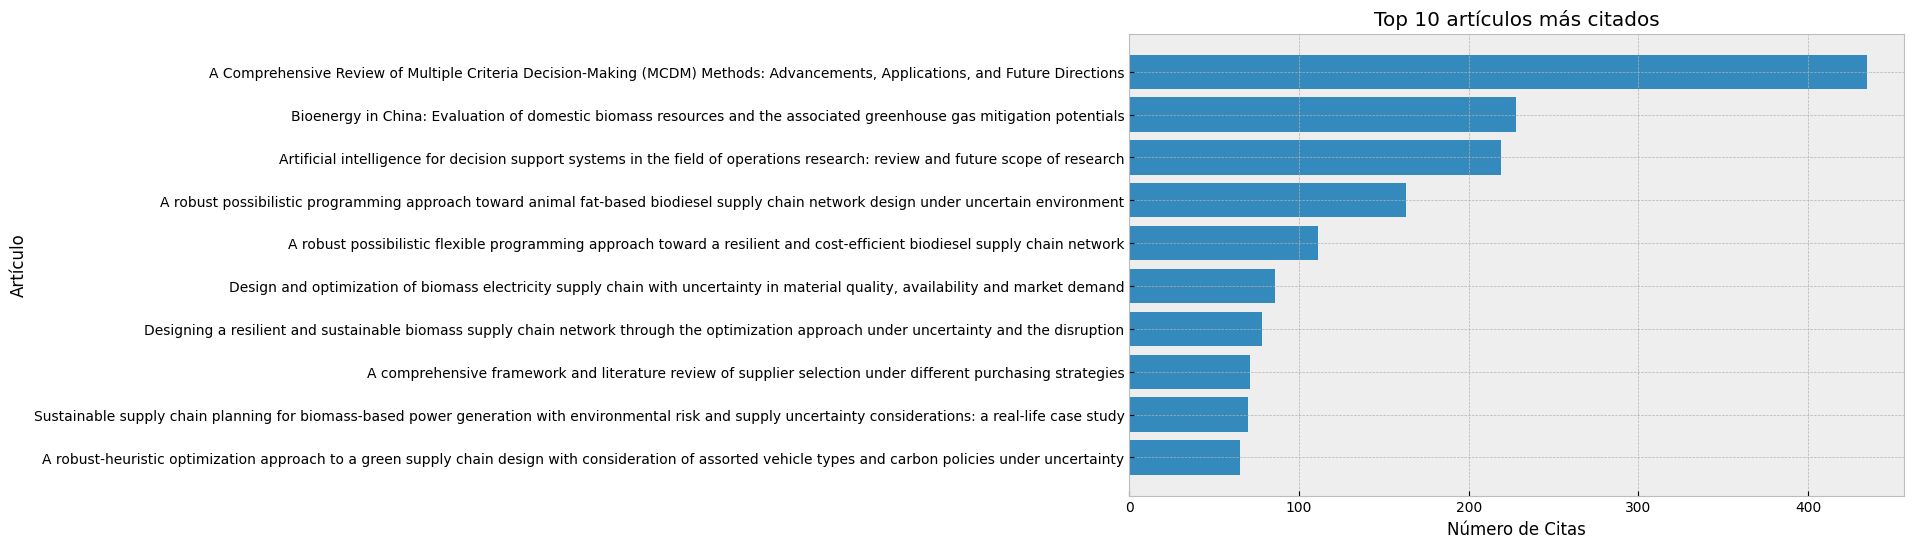

In [18]:

with open("/content/scopus1403400.bib", encoding="utf-8") as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)

titulos = []
citas = []

for entry in bib_database.entries:
    titulos.append(entry.get("title", "Sin título"))
    note_field = entry.get("note", "")
    match = re.search(r"Cited by:\s*(\d+)", note_field)
    citas.append(int(match.group(1)) if match else 0)

df_citas = pd.DataFrame({
    "Título": titulos,
    "Citas": citas
})

df_citas = df_citas.sort_values(by="Citas", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_citas["Título"].head(10), df_citas["Citas"].head(10))
plt.xlabel("Número de Citas")
plt.ylabel("Artículo")
plt.title("Top 10 artículos más citados")
plt.gca().invert_yaxis()
plt.show()


# **Análisis de redes de conocimiento**

*1- Colaboración entre países*

In [19]:
# Network - Collaboration Analysis Between Countries using a Map. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            connections = True or False (True -> Countries connections will be displayed, False -> Countries connections will not be displayed);
#            country_lst = Highlight the Connections Between a List of Countries
bibfile.network_adj_map(view = 'notebook', connections = True, country_lst = ["colombia"])

*2- Relación entre palabras clave*

In [20]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'kwa', min_count = 50, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



*3. Colaboración entre autores*

In [21]:
# Network - Collaboration Analysis Between Authors, Countries, Intitutions Or Adjacency Analysis Between Authors' Keywords or Keywords Plus. (An interactive plot).
# Arguments: view        = 'notebook', 'browser' ('notebook' -> To plot in your prefered Notebook App. 'browser' -> To plot in your prefered browser window);
#            adj_type    = 'aut', 'cout', 'inst', 'kwa', or 'kwp'
#            min_count   = Relationship between nodes that have connected at least x times;
#            node_labels = True or False (True -> The label IDs will be displayed, False -> Only the nodes will be displayed );
#            node_size   = -1. (If node_size = -1 then the default value will be used. If node_size > 0 then this new value will be used);
#            label_type  = 'id', 'name' (Only meaningfull if node_labels = True. 'id' -> The ID will be displayed; 'name' -> The name will be displayed);
#            centrality  = 'degree', 'load', 'betw', 'close', 'eigen', 'katz', 'harmonic', or None. Color nodes according to centrality criterion
#                          'degree'   = Degree Centrality
#                          'load'     = Load Centrality
#                          'betw'     = Betweenness Centrality
#                          'close'    = Closeness Centrality
#                          'eigen'    = Eigenvector Centrality
#                          'katz'     = Katz Centrality
#                          'harmonic' = Harmonic Centrality
#                           None      = The Community Algorithm, Girvan-Newman, will be used Instead of a Centrality Criterion
bibfile.network_adj(view = 'notebook', adj_type = 'aut', min_count = 16, node_labels = True, label_type = 'name', centrality = 'eigen')

# PS: If a centrality criterion is used then the values can be obtained by the following command:  bibfile.table_centr

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning:

Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.



# **Preparando datos para clustering de texto**

*1. Importamos módulos*

In [22]:
import nltk
from nltk.corpus import stopwords
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import umap
import hdbscan

*2. Filtramos palabras*


In [23]:
nltk.download('stopwords')
base_stop_words = list(stopwords.words('english'))

my_extra_words = [
    'biomass', 'supply', 'chain', 'model', 'optimization', 'approach', "using", "used", "use", "proposed", "propose", "considered", "considering", "shows", "paper", "research", "work",
    'results', 'problem', 'energy', 'production', "method", "methodology", "framework", "application", "case", "based", "evaluation", "results", "system", "systems", "models",
    'study', 'paper', 'analysis', "copyright", "elsevier", "springer", "wiley", "mdpi", "ieee", "doi", "http", "https", "pdf", "journal", "article", "issue", "volume",
]

final_stop_words = base_stop_words + my_extra_words

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


*3. Configuramos el vectorizador*

In [24]:
vectorizer_model = CountVectorizer(stop_words=final_stop_words, ngram_range=(1, 4))

*4. Configuramos c-TF-IDF*

In [25]:
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)

*5. Creamos diccionario con categorias de modelos de optimización*

In [26]:
optimization_models = {

    "stochastic_programming": ["stochastic programming", "two stage stochastic", "two-stage stochastic", "multi stage stochastic", "multi-stage stochastic", "scenario based",
        "scenario-based", "recourse", "chance constrained"
    ],
    "robust_optimization": ["robust optimization", "distributionally robust", "robust model", "uncertainty set"
    ],
    "multiobjective_optimization": ["multi objective optimization", "multi-objective optimization", "pareto optimization"
    ],
    "simulation_based": ["monte carlo simulation", "monte carlo", "simulation model"
    ]
}


def analyze_optimization(text):
    text = text.lower()
    results = {}
    for cat, terms in optimization_models.items():
        # Buscamos coincidencias
        matches = [term for term in terms if re.search(rf"\b{term}\b", text)]
        results[cat] = len(matches) > 0
    return results

df_final = bibfile.data
df_final['analysis'] = df_final['abstract'].apply(analyze_optimization)

In [27]:
df_final[['title', 'analysis']].head()
df_final['analysis'] = df_final['abstract'].apply(analyze_optimization)
df_final

,abbrev_source_title,abstract,address,affiliation,affiliations,art_number,author,author_keywords,chemicals_cas,coden,...,pubmed_id,references,source,sponsors,title,tradenames,url,volume,year,analysis
0,Sustainability,Natural fiber-based biocomposites are rapidly ...,UNKNOWN,"Akbarian-Saravi, Niloofar Composites Research ...",Composites Research Network-Okanagan Laborator...,UNKNOWN,"Akbarian-Saravi, Niloofar and Sowlati, Taraneh...",analytic network process; biocomposites; optim...,UNKNOWN,UNKNOWN,...,UNKNOWN,UNKNOWN,Scopus,UNKNOWN,A Robust Analytical Network Process for Biocom...,UNKNOWN,https://www.scopus.com/inward/record.uri?eid,17,2025,"{'stochastic_programming': False, 'robust_opti..."
1,Comput Ind Eng,This paper introduces an innovative approach f...,UNKNOWN,"Alizadeh, Mohammadmahdi Department of Industri...",Department of Industrial Engineering and Manag...,UNKNOWN,"Alizadeh, Mohammadmahdi and Karimi, Behrooz",Downstream oil supply chain; Mixed possibilist...,UNKNOWN,CINDD,...,UNKNOWN,UNKNOWN,Scopus,UNKNOWN,A dynamic two-phased approach for planning dow...,UNKNOWN,https://www.scopus.com/inward/record.uri?eid,194,2024,"{'stochastic_programming': False, 'robust_opti..."
2,Energy Convers. Manage.,The growing global population and the need for...,UNKNOWN,"Alinejad, Saeed Management Department, Faculty...","Management Department, Faculty of Economics, M...",UNKNOWN,"Alinejad, Saeed and Alimohammadlou, Moslem and...",Biomass management challenges; CIF-DEMATEL; CI...,UNKNOWN,ECMAD,...,UNKNOWN,UNKNOWN,Scopus,UNKNOWN,Smart-Circular strategies for managing biomass...,UNKNOWN,https://www.scopus.com/inward/record.uri?eid,314,2024,"{'stochastic_programming': False, 'robust_opti..."
3,Sustainable Energy Technol. Assess.,The commercial deployment of cellulosic biofue...,UNKNOWN,"Wan, Linwei School of Economics and Management...","School of Economics and Management, Henan Univ...",UNKNOWN,"Wan, Linwei and Zhang, Zijin and Xing, Wentao",Biofuel logistics; Gasification‑pyrolysis syst...,UNKNOWN,UNKNOWN,...,UNKNOWN,UNKNOWN,Scopus,UNKNOWN,Comprehensive techno economic and logistic ass...,UNKNOWN,https://www.scopus.com/inward/record.uri?eid,86,2026,"{'stochastic_programming': False, 'robust_opti..."
4,Logist.,Background: Brazil’s bioethanol supply chain i...,UNKNOWN,"Santos, Edson da Silva Department of Managemen...","Department of Management Engineering, Federal ...",UNKNOWN,"Santos, Edson da Silva and Silva, Wesley Dougl...",bioethanol; circular economy; group decision m...,UNKNOWN,UNKNOWN,...,UNKNOWN,UNKNOWN,Scopus,UNKNOWN,Circular Strategic Options for Ethanol Supply ...,UNKNOWN,https://www.scopus.com/inward/record.uri?eid,9,2025,"{'stochastic_programming': False, 'robust_opti..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,Front. Bioeng. Biotechnol.,Variable moisture content of biomass during st...,UNKNOWN,"Smith, William A. Idaho National Laboratory, I...","Idaho National Laboratory, Idaho Falls, ID, Un...",UNKNOWN,"Smith, William A. and Wendt, Lynn M. and Bonne...",aerobic storage; biomass; composition; dry mat...,UNKNOWN,UNKNOWN,...,UNKNOWN,UNKNOWN,Scopus,UNKNOWN,Effects of Storage Moisture Content on Corn St...,UNKNOWN,https://www.scopus.com/inward/record.uri?eid,8,2020,"{'stochastic_programming': False, 'robust_opti..."
396,J. Clean. Prod.,Integrated biorefineries offer an efficient wa...,UNKNOWN,"Co, Daniel Vincent Y. Department of Industrial...",Department of Industrial and Systems Engineeri...,UNKNOWN,"Co, Daniel Vincent Y. and Lim, Andrei Shaun O....",Biomass feedstock; Multi-objective optimizatio...,UNKNOWN,JCROE,...,UNKNOWN,UNKNOWN,Scopus,UNKNOWN,Integrating heterogenous robustness levels to ...,UNKNOWN,https://www.scopus.com/inward/record.uri?eid,475,2024,"{'stochastic_programming': False, 'robust_opti..."
397,GCB Bioenergy,This study performs techno-economic analysis a...,UNKNOWN,"Lan, Kai Department of Forest Biomaterials, No...","Department of Forest Biomaterials, North Ca

*5. Detección de términos de optimización aplicados en los abstracks*

In [28]:
all_terms = [term for sublist in optimization_models.values() for term in sublist]

pattern = '|'.join([rf"\b{re.escape(t)}\b" for t in all_terms])

mask = df_final["abstract"].str.contains(pattern, case=False, na=False)

# **Creación de embedding**

In [29]:
df_opt = df_final[mask].copy().reset_index(drop=True)
docs_finales = df_opt["abstract"].tolist()

embedding_model = SentenceTransformer("allenai/scibert_scivocab_uncased")
embeddings_raw = embedding_model.encode(docs_finales, show_progress_bar=True)
embeddings_finales_np = np.array(embeddings_raw)

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

# **Modelado de topicos**

*1. Creando modelo Bertropic*

In [30]:

umap_model = umap.UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=1, metric='euclidean', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words="english", ngram_range=(1, 4))


topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    ctfidf_model=ctfidf_model,
    nr_topics=5,
    verbose=True
)


topics, probs = topic_model.fit_transform(docs_finales, embeddings_finales_np)



2026-03-19 02:12:26,196 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 02:12:45,263 - BERTopic - Dimensionality - Completed ✓
2026-03-19 02:12:45,265 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 02:12:45,323 - BERTopic - Cluster - Completed ✓
2026-03-19 02:12:45,324 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-19 02:12:45,691 - BERTopic - Representation - Completed ✓
2026-03-19 02:12:45,693 - BERTopic - Topic reduction - Reducing number of topics
2026-03-19 02:12:45,708 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 02:12:46,053 - BERTopic - Representation - Completed ✓
2026-03-19 02:12:46,056 - BERTopic - Topic reduction - Reduced number of topics from 12 to 5


*2. Creamos topicos*

In [31]:
new_topics = topic_model.reduce_outliers(docs_finales, topics, probabilities=probs, strategy="probabilities")

topic_model.update_topics(docs_finales, topics=new_topics)

df_opt["topic"] = new_topics


2026-03-19 02:12:56,859 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [32]:
topic_info = topic_model.get_topic_info()

topic_info.head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,0,62,0_the_of_and_to,"[the, of, and, to, in, is, supply, model, chai...",[Due to a wide variety of real-world constrain...
1,1,58,1_the_and_of_to,"[the, and, of, to, in, is, for, model, supply,...","[The growth in global population, pollution, a..."
2,2,10,2_and_the_to_of,"[and, the, to, of, biomass, in, for, that, met...",[As a potential source of low-carbon transport...
3,3,6,3_the_of_biomass_supply,"[the, of, biomass, supply, to, is, chain, micr...",[Microalgae biomass is currently gaining the l...


*3. Visualizando topicos*

In [33]:
topic_model.visualize_topics()

In [34]:
topic_model.get_topic(0)

[('the', np.float64(0.12152650511708733)),
 ('of', np.float64(0.07707354124465202)),
 ('and', np.float64(0.07199707679704215)),
 ('to', np.float64(0.06221153874368813)),
 ('in', np.float64(0.04954786853251856)),
 ('is', np.float64(0.04686079096405382)),
 ('supply', np.float64(0.04328461066404004)),
 ('model', np.float64(0.04123064199943377)),
 ('chain', np.float64(0.03630277156196795)),
 ('for', np.float64(0.03055699757081864))]

In [35]:
df_opt["topic"] = topics

In [36]:
def extraer_categoria(texto, diccionario, default="not_specified"):
    if not isinstance(texto, str):
        return default

    texto = texto.lower()
    for categoria, palabras_clave in diccionario.items():
        # Usamos regex para buscar palabras completas y evitar errores
        for keyword in palabras_clave:
            if re.search(r'\b' + re.escape(keyword.lower()) + r'\b', texto):
                return categoria
    return default

# **Creación de categorias de investigación**

*1. Creando diccionarios de interés*

In [50]:
optimization_models = {

    "stochastic_programming": ["stochastic programming", "two-stage stochastic*", "multi-stage stochastic*", "scenario based", "recourse", "chance constrained"],
    "robust_optimization": ["robust optimization", "distributionally robust", "robust model*", "uncertainty set*"],
    "multiobjective_optimization": ["multi-objective optimization", "multiobjective optimization", "pareto optimization"],
    "simulation_based": ["monte carlo simulation*", "monte carlo", "simulation model*"]
}



In [55]:
categories_methods = {
    "exact_methods": ["linear programming", "milp", "mixed-integer*", "nlp", "nonlinear programming", "exact method*", "branch and bound", "benders decomposition", "cplex", "gurobi"],
    "machine_learning_ann": ["machine learning", "deep learning", "neural network*", "ann", "cnn", "rnn", "supervised learning", "unsupervised learning", "random forest*", "support vector machine*"],
    "metaheuristics": ["genetic algorithm*", "particle swarm*", "simulated annealing", "metaheuristic*", "ant colony", "heuristic algorithm*"],
    "reinforcement_learning": ["reinforcement learning", "q-learning", "deep q-network*"],
    "bayesian_frameworks": ["bayesian*", "probabilistic graphical model*", "gaussian process*"]
}

In [39]:

uncertainty_categories = {

    "supply_upstream": ["supply uncertainty", "biomass availability", "feedstock shortage*", "uncertain yield*", "biomass variability", "collection volume*"],
    "feedstock_quality": ["moisture content*", "calorific value*", "ash content*", "impurities", "feedstock quality", "heating value*", "hhv", "lhv"],
    "logistics_transport": ["transportation time*", "lead time*", "delivery delay*", "road closure*", "logistics risk*", "disruption*", "resilience"],
    "economic_market": ["price fluctuation*", "cost uncertainty", "investment risk*", "fuel price*", "market price*", "operational cost*", "inflation"],
    "demand_downstream": ["market requirement*", "consumption", "customer needs", "uncertain demand*", "stochastic demand*", "demand volatility"],
    "process_technical": ["biorefinery uncertainty", "conversion uncertain*", "technology uncertainty", "conversion efficiency", "biorefinery yield*"]

    }

In [40]:
applications = {

    "strategic_network_design": ["supply chain design", "supply chain network*", "network design", "facility location", "infrastructure planning", "supply chain configuration"],
    "logistics_transportation": ["transportation", "biomass transportation", "logistics", "biomass logistics", "transportation planning", "transport cost*", "vehicle routing", "distribution"],
    "biorefinery_conversion": ["biorefinery", "biofuel production", "bioenergy system*", "biogas production", "biomass conversion", "conversion technology"],
    "inventory_storage": ["inventory management", "biomass storage", "safety stock*", "stock level*", "warehousing", "storage capacity"],
    "harvesting_collection": ["biomass harvesting", "biomass collection", "feedstock supply", "feedstock availability", "crop residue*", "gathering"],
    "market_economic_analysis": ["energy market*", "biofuel market*", "market demand", "consumption", "consumer behavior", "market penetration"]

}


In [41]:
sustainability = {
    "environmental": ["carbon footprint", "lca", "life cycle assessment", "emissions", "ghg", "environmental impact", "global warming"],
    "economic": ["npv", "irr", "total cost", "profitability", "economic feasibility", "payback period"],
    "social": ["job creation", "social impact", "rural development", "social acceptance", "labor safety"]
}

In [42]:
scale = {

    "spatial": ["gis", "geographic information system*", "regional scale", "national scale", "global scale", "spatial analysis"],
    "temporal": ["multi-period", "multi-stage", "dynamic model*", "long-term", "short-term", "daily", "monthly"]
}

In [43]:
ai_methods_vanguardia = {
    "Machine_Learning_Classic": ["supervised learning", "random forest*", "svm", "decision tree*", "regression", "knn", "gradient boosting"],
    "Deep_Learning_Architectures": ["neural network*", "ann", "cnn", "lstm", "rnn", "transformer*", "mlp", "deep learning"],
    "Reinforcement_Learning": ["reinforcement learning", "q-learning", "dqn", "agent-based", "policy gradient*", "multi-agent"],
    "Physics_Informed_AI": ["pinn", "physics-informed", "hybrid modeling", "mechanistic-informed"],
    "Explainable_AI_XAI": ["explainable ai", "xai", "shap", "lime", "interpretability", "feature importance"],
    "Generative_AI_LLM": ["generative ai", "llm", "gpt", "large language model*", "gan", "variational autoencoder*", "langchain"],
    "IA_Integrated_Optimization": ["surrogate model*", "meta-modeling", "ai-driven optimization", "neural optimization"]
}

In [44]:
objective_dict = {
    "Economic": ["cost*", "profit*", "revenue*", "npv", "economic*", "financial*", "capex", "opex", "roi"],
    "Environmental": ["emission*", "ghg", "carbon*", "environmental*", "lca", "pollution", "footprint*", "gwp"],
    "Social": ["job*", "social*", "employment", "stakeholder*", "communit*", "safety"],
    "Technical_Service": ["demand fulfillment", "distance", "lead time", "reliability", "efficiency", "inventory level*"],
    "Resilience_Risk": ["resilience", "risk*", "cvar", "robustness", "disruption*", "variability"],
    "Resource_Circular": ["circular*", "waste*", "water footprint", "recycling", "resource depletion"]
}

In [94]:
decision_categories = {
    "facility_location": ["location", "siting", "network design", "warehouse", "allocation", "strategic design"],
    "pretreatment": ["pretreatment", "drying", "pelletization", "torrefaction", "anaerobic", "biochemical", "mechanical", "chemical", "densification", "grinding", "briquetting", "pyrolysis", "gasification"],
    "logistics_routing": ["routing", "vehicle routing", "vrp", "scheduling", "fleet", "transportation", "last-mile", "transportation planning"],
    "inventory_mgt": ["inventory", "stock", "storage", "buffer", "safety stock"],
    "capacity_planning": ["capacity expansion", "scaling", "modular design", "investment"]

}

# **Evolución de los métodos de optimización**

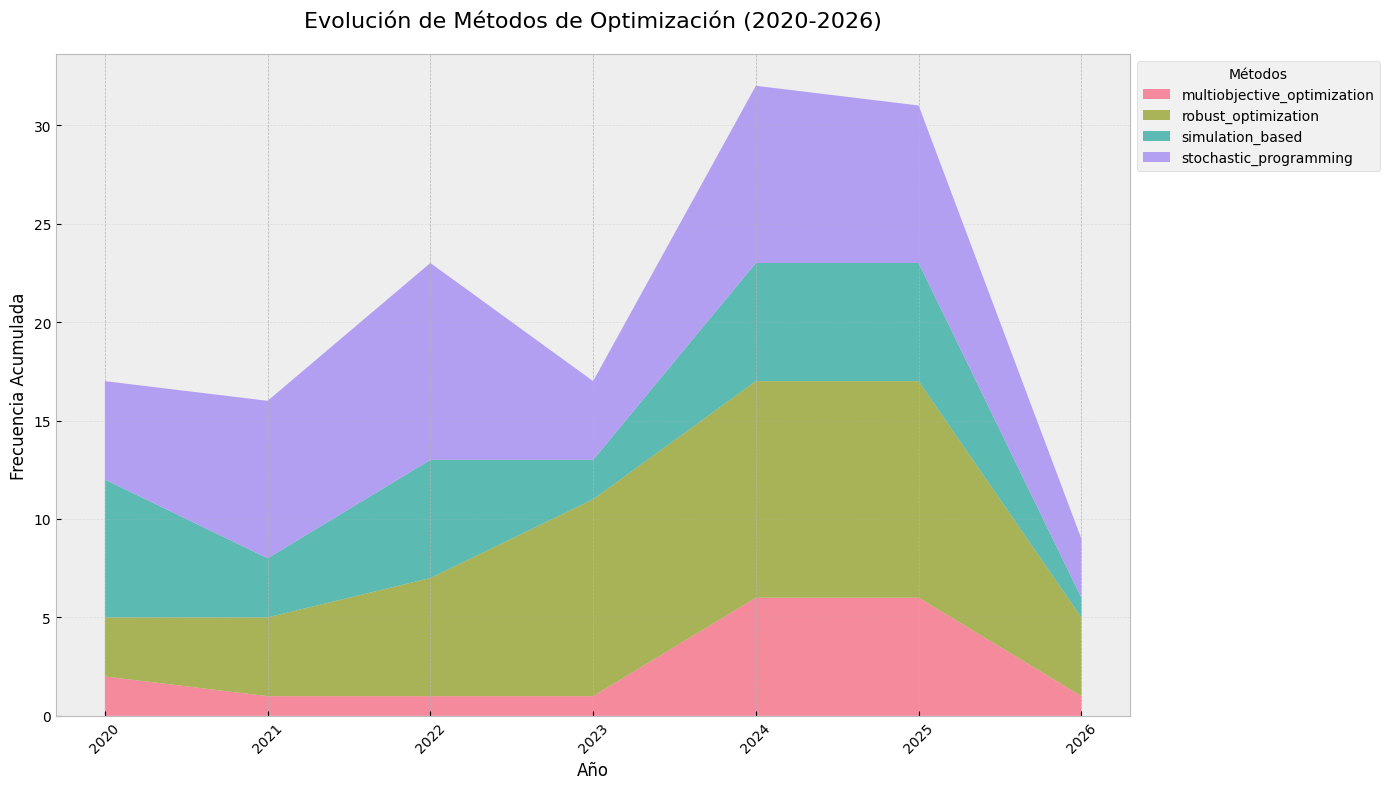

In [95]:
# PARTE 1: PROCESAMIENTO

df_opt['year'] = pd.to_numeric(df_opt['year'], errors='coerce')
df_opt['methods_dict'] = df_opt['abstract'].apply(analyze_optimization)
methods_df = df_opt['methods_dict'].apply(pd.Series)
df_temporal = pd.concat([df_opt[['year']], methods_df], axis=1)
df_plot = df_temporal.melt(id_vars=['year'], var_name='Method', value_name='Present')
df_plot = df_plot.dropna(subset=['year'])
df_plot = df_plot[df_plot['Present'] == True]
evolution = df_plot.groupby(['year', 'Method']).size().reset_index(name='count')

# PARTE 2: GRÁFICA

pivot_evolution = evolution.pivot(index='year', columns='Method', values='count').fillna(0)
plt.figure(figsize=(14, 8))
paleta = sns.color_palette("husl", len(pivot_evolution.columns))

plt.stackplot(
    pivot_evolution.index,
    pivot_evolution.T,
    labels=pivot_evolution.columns,
    colors=paleta,
    alpha=0.8
)

plt.title('Evolución de Métodos de Optimización (2020-2026)', fontsize=16, pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Frecuencia Acumulada', fontsize=12)
plt.legend(loc='upper left', title="Métodos", bbox_to_anchor=(1, 1))

plt.xticks(pivot_evolution.index.astype(int), rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# **Preguntas de investigación**

In [96]:
all_dicts = {
    "Models": optimization_models,
    "Methods": categories_methods,
    "Uncertainty": uncertainty_categories,
    "Applications": applications,
    "Sustainability": sustainability,
    "Scale": scale,
    "ai_methods_vanguardia": ai_methods_vanguardia,
    "objective_dict": objective_dict,
    "decision_categories": decision_categories
}

In [97]:
def create_cooccurrence_matrix(df, col_row, col_col, dict_row, dict_col):

    matrix = pd.DataFrame(0, index=dict_row.keys(), columns=dict_col.keys())

    for _, row in df.iterrows():

        labels_row = row.get(col_row, [])
        labels_col = row.get(col_col, [])

        if isinstance(labels_row, str): labels_row = [labels_row]
        if isinstance(labels_col, str): labels_col = [labels_col]

        for r in labels_row:
            for c in labels_col:
                if r in matrix.index and c in matrix.columns:
                    matrix.loc[r, c] += 1
    return matrix

In [99]:
def check_presence_pro(row, dictionary):

    full_text = f"{row.get('title', '')} {row.get('abstract', '')} {row.get('keywords', '')}".lower()
    found = []

    for cat, terms in dictionary.items():
        for term in terms:
            term = term.lower().strip()
            if term.endswith('*'):
                base_term = re.escape(term[:-1])
                pattern = r'\b' + base_term + r'\w*\b'
            else:
                pattern = r'\b' + re.escape(term) + r'\b'

            if re.search(pattern, full_text):
                found.append(cat)
                break
    return found

# Ejecutar detección
for col_name, d_dict in all_dicts.items():
    df_final[col_name] = df_final.apply(lambda row: check_presence_pro(row, d_dict), axis=1)

m1 = create_cooccurrence_matrix(df_final, "Applications", "Methods", applications, categories_methods)
m2 = create_cooccurrence_matrix(df_final, "Uncertainty", "Models", uncertainty_categories, optimization_models)
m3 = create_cooccurrence_matrix(df_final, "Applications", "Sustainability", applications, sustainability)
m4 = create_cooccurrence_matrix(df_final, "Models", "Scale", optimization_models, scale)
m5 = create_cooccurrence_matrix(df_final, "Uncertainty", "Sustainability", uncertainty_categories, sustainability)
m6 = create_cooccurrence_matrix(df_final, "Methods", "Scale", categories_methods, scale)
m7 = create_cooccurrence_matrix(df_final, "Uncertainty", "Models", uncertainty_categories, optimization_models)
m8 = create_cooccurrence_matrix(df_final, "ai_methods_vanguardia", "Applications", ai_methods_vanguardia, applications)
m9 = create_cooccurrence_matrix(df_final, "ai_methods_vanguardia", "Uncertainty", ai_methods_vanguardia, uncertainty_categories)
m10 = create_cooccurrence_matrix(df_final, "Methods", "objective_dict", categories_methods, objective_dict)
m11 = create_cooccurrence_matrix(df_final, "decision_categories", "Uncertainty", decision_categories, uncertainty_categories)


*¿Existen eslabones de la cadena de biomasa que aún no han sido abordados con técnicas de vanguardia (IA/Reinforcement Learning)?*

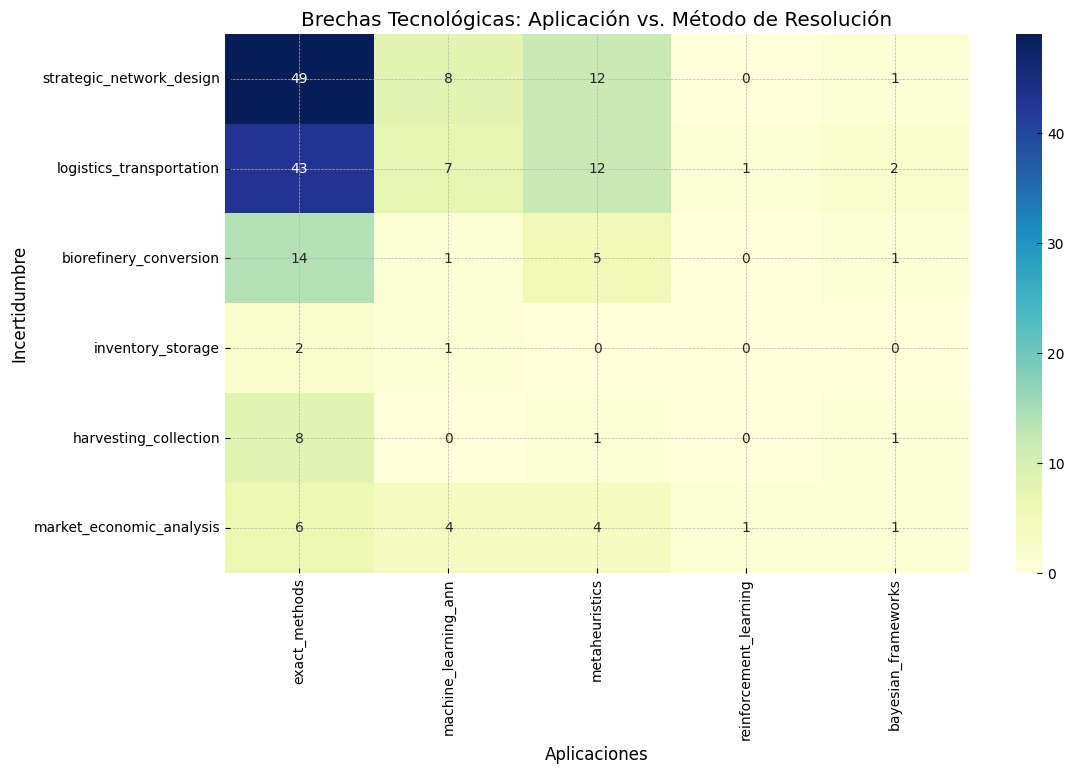

In [60]:
plt.figure(figsize=(12, 7))
sns.heatmap(m1, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Brechas Tecnológicas: Aplicación vs. Método de Resolución")
plt.xlabel("Aplicaciones")
plt.ylabel("Incertidumbre")
plt.show()

*¿Qué tipo de incertidumbre estamos ignorando al usar modelos determinísticos o estocásticos?*

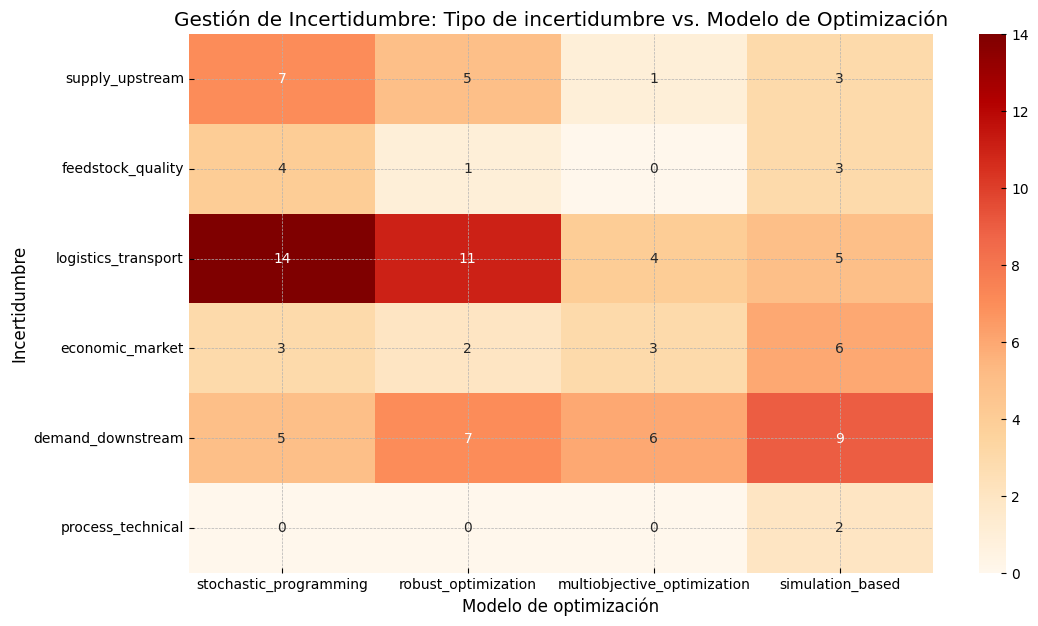

In [61]:
plt.figure(figsize=(12, 7))
sns.heatmap(m2, annot=True, fmt="d", cmap="OrRd")
plt.title("Gestión de Incertidumbre: Tipo de incertidumbre vs. Modelo de Optimización")
plt.xlabel("Modelo de optimización")
plt.ylabel("Incertidumbre")
plt.show()

*¿La investigación en logística y diseño de red es puramente económica o integra dimensiones sociales y ambientales?*

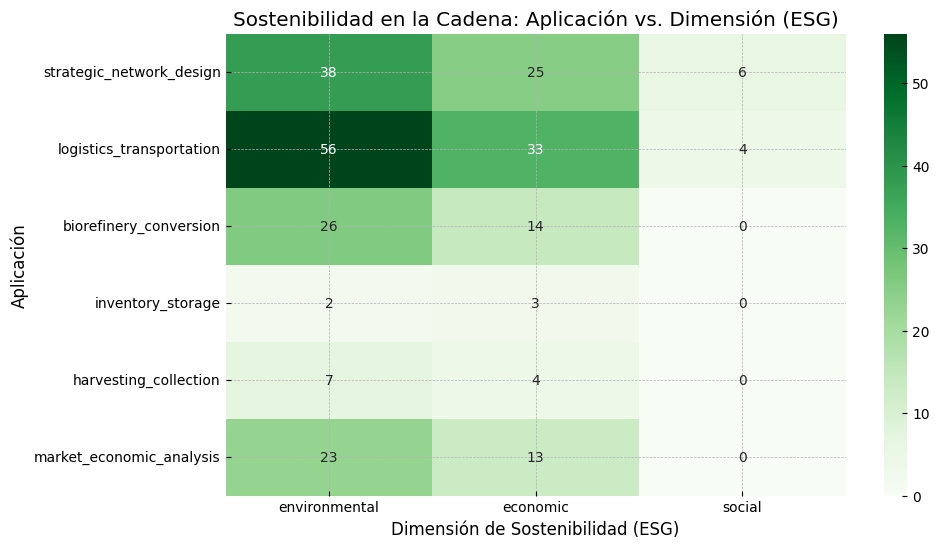

In [62]:
plt.figure(figsize=(10, 6))
sns.heatmap(m3, annot=True, fmt="d", cmap="Greens")
plt.title("Sostenibilidad en la Cadena: Aplicación vs. Dimensión (ESG)")
plt.xlabel("Dimensión de Sostenibilidad (ESG)")
plt.ylabel("Aplicación")
plt.show()

*¿Los modelos avanzados (Estocásticos/Robustos) están incorporando la complejidad espacial (GIS) y temporal necesaria para ser realistas en el mundo de la biomasa?*

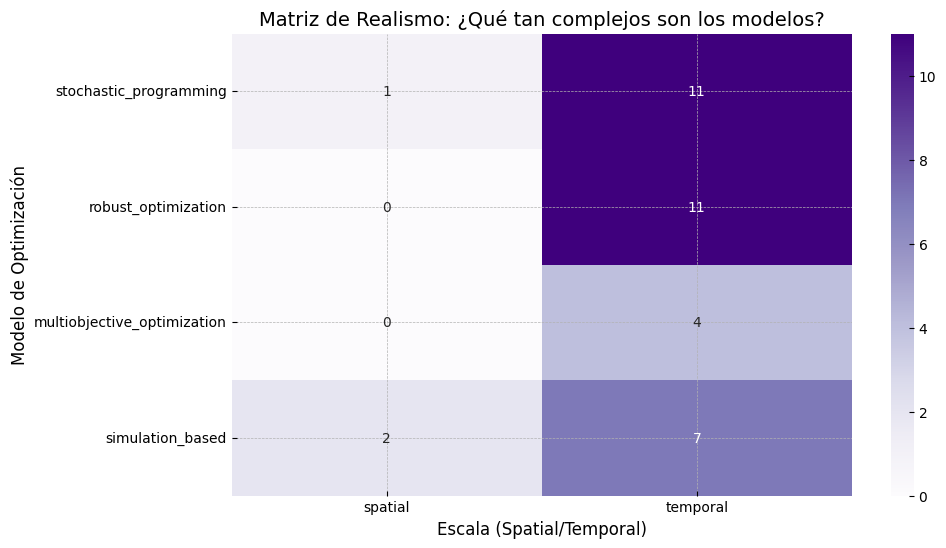

In [63]:
# Matriz de Realismo: Modelos de Optimización vs Escala (Espacial/Temporal)

plt.figure(figsize=(10, 6))
sns.heatmap(m4, annot=True, fmt="d", cmap="Purples")
plt.title("Matriz de Realismo: ¿Qué tan complejos son los modelos?", fontsize=14)
plt.xlabel("Escala (Spatial/Temporal)")
plt.ylabel("Modelo de Optimización")
plt.show()

*¿Se analiza el impacto de la incertidumbre en las dimensiones Sociales y Ambientales, o la literatura solo se protege del Riesgo Económico?*

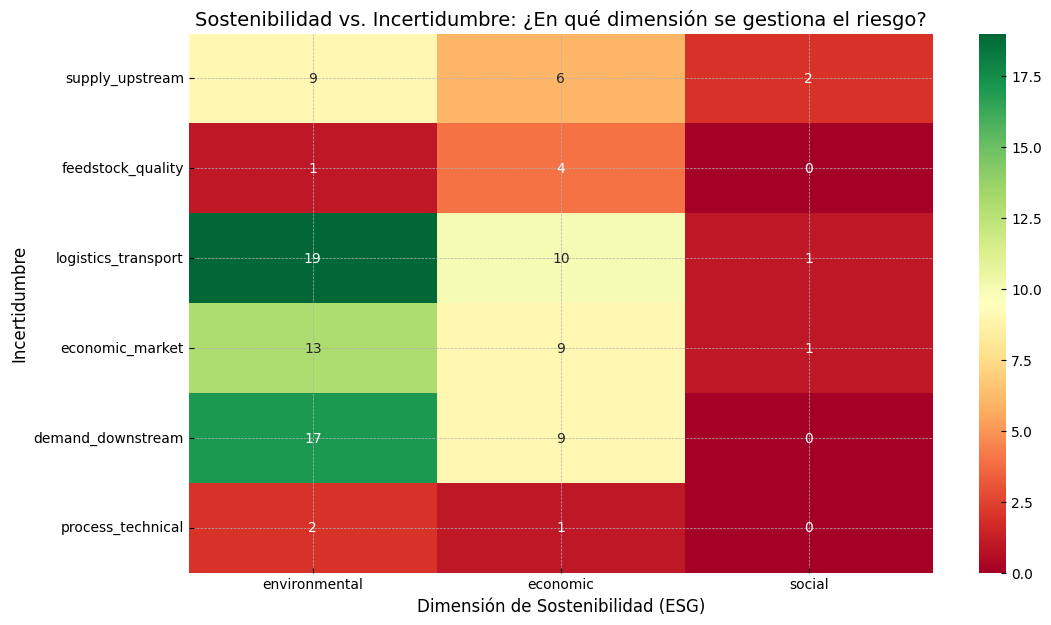

In [64]:
plt.figure(figsize=(12, 7))
sns.heatmap(m5, annot=True, fmt="d", cmap="RdYlGn")
plt.title("Sostenibilidad vs. Incertidumbre: ¿En qué dimensión se gestiona el riesgo?", fontsize=14)
plt.xlabel("Dimensión de Sostenibilidad (ESG)")
plt.ylabel("Incertidumbre")
plt.show()


*¿Se están usando Metaheurísticas debido a la gran escala del problema (Nacional/Global) o se aplican incluso en problemas pequeños donde un método exacto sería mejor?*

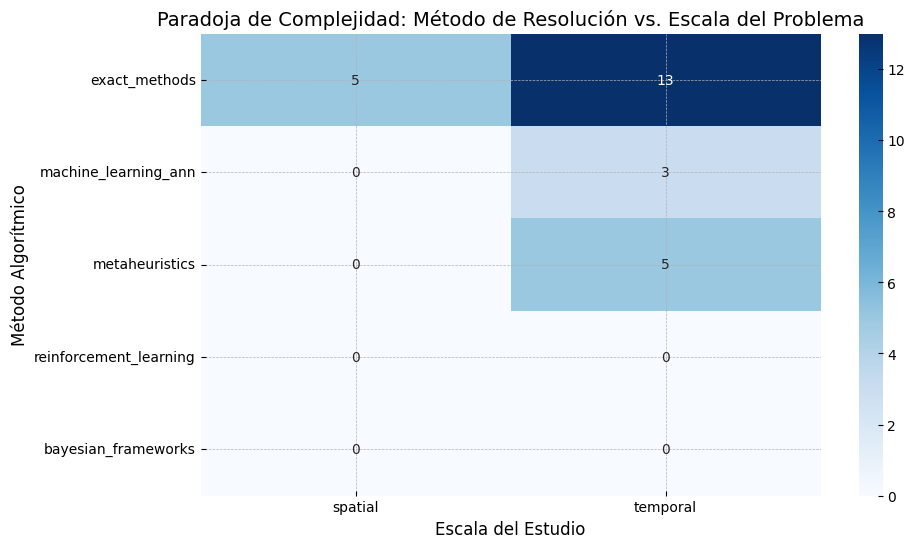

In [65]:
plt.figure(figsize=(10, 6))
sns.heatmap(m6, annot=True, fmt="d", cmap="Blues")
plt.title("Paradoja de Complejidad: Método de Resolución vs. Escala del Problema", fontsize=14)
plt.xlabel("Escala del Estudio")
plt.ylabel("Método Algorítmico")
plt.show()


*¿Tenemos una "herramienta favorita" para cada riesgo? ¿La calidad de la biomasa se optimiza o solo se simula?*

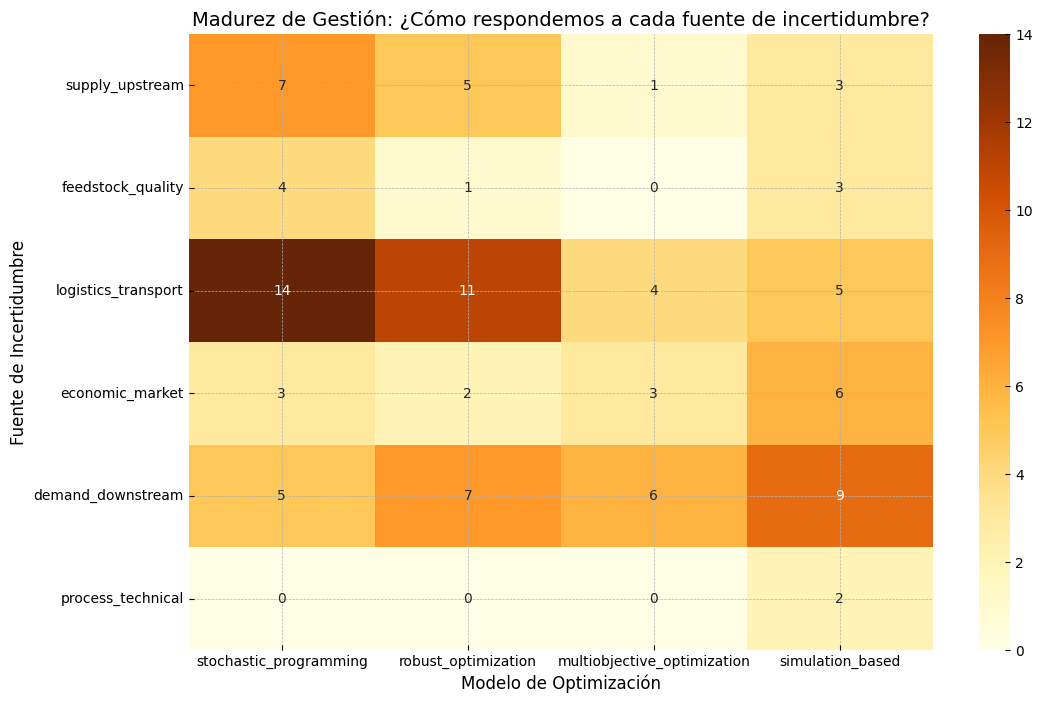

In [66]:
plt.figure(figsize=(12, 8))
sns.heatmap(m7, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Madurez de Gestión: ¿Cómo respondemos a cada fuente de incertidumbre?", fontsize=14)
plt.xlabel("Modelo de Optimización")
plt.ylabel("Fuente de Incertidumbre")
plt.show()


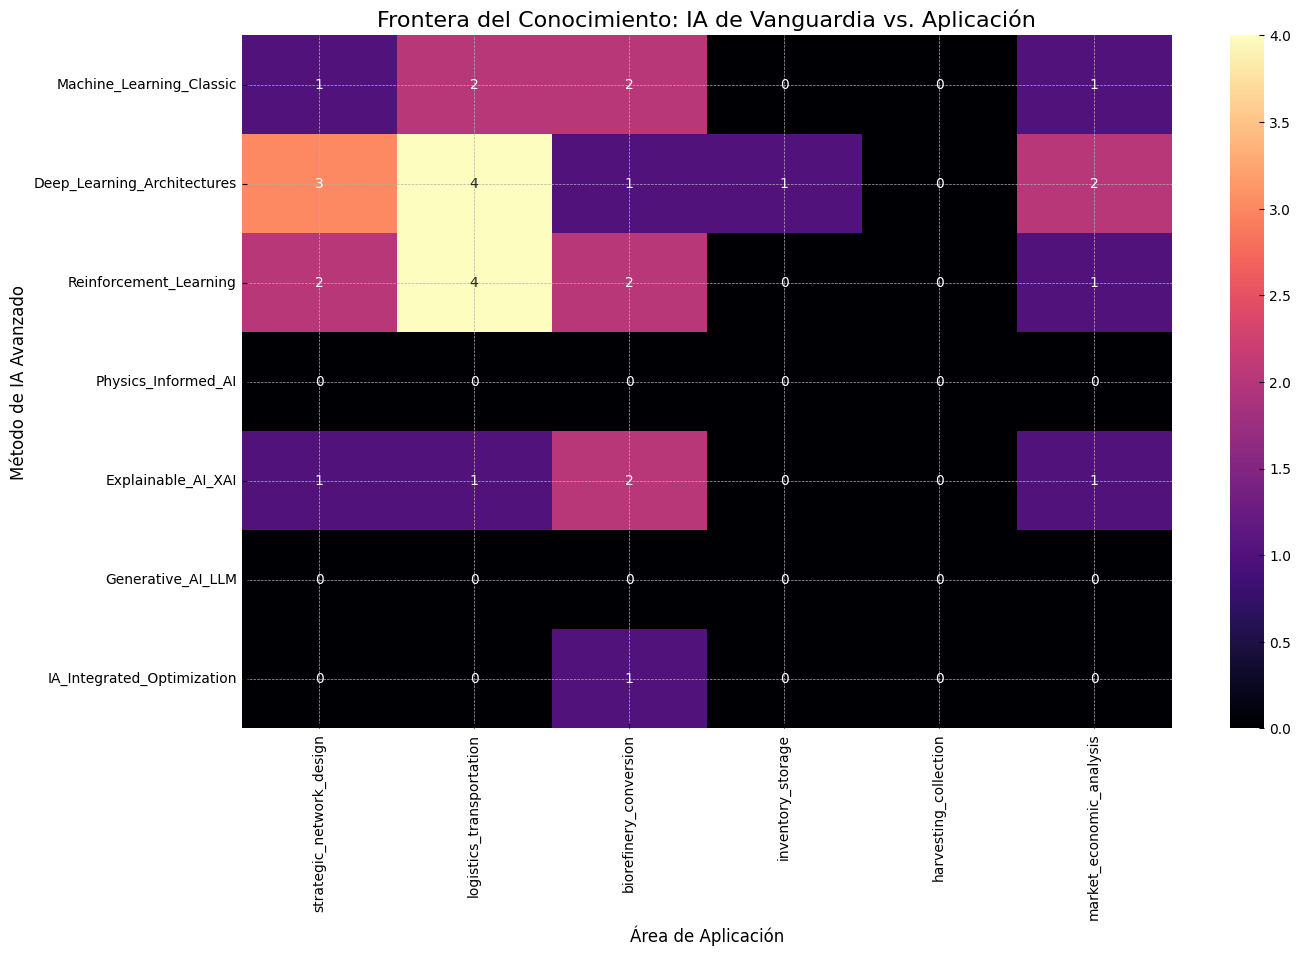

In [67]:
plt.figure(figsize=(15, 9))
sns.heatmap(m8, annot=True, fmt="d", cmap="magma")
plt.title("Frontera del Conocimiento: IA de Vanguardia vs. Aplicación", fontsize=16)
plt.xlabel("Área de Aplicación")
plt.ylabel("Método de IA Avanzado")
plt.show()

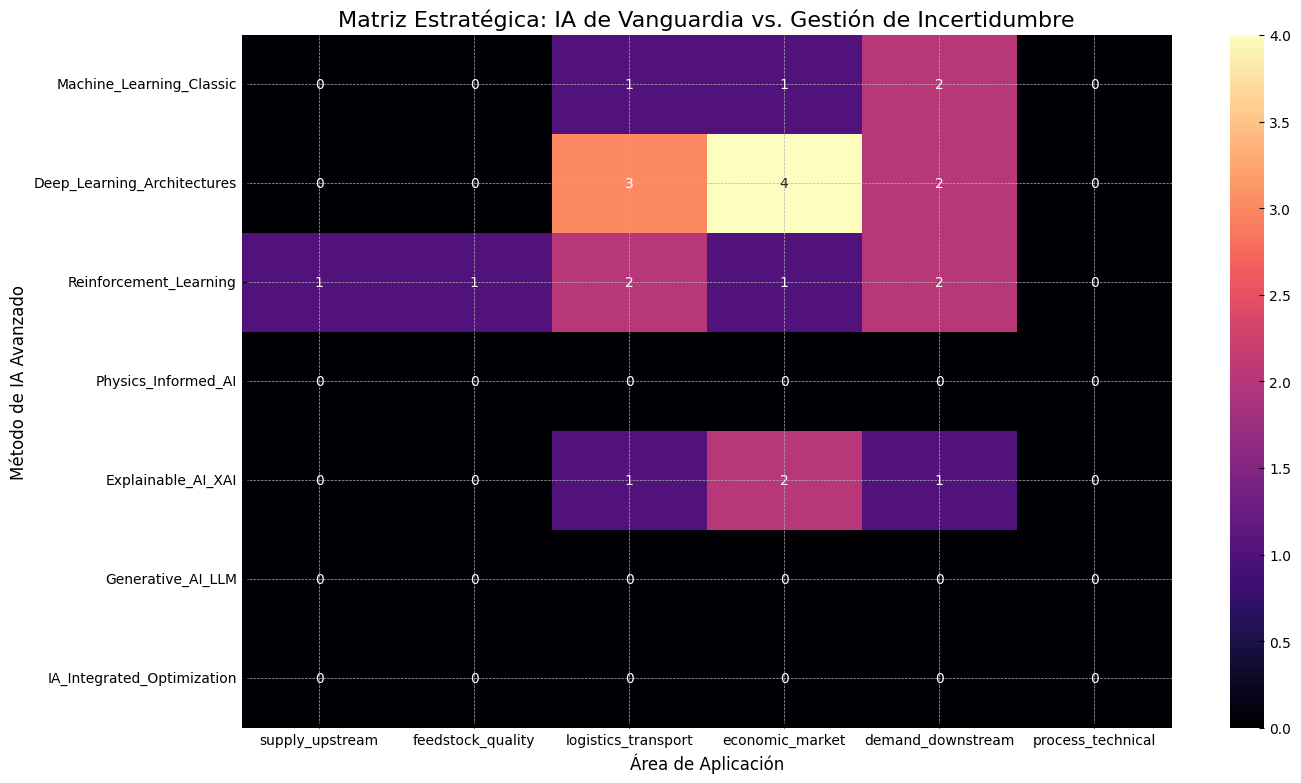

In [71]:
plt.figure(figsize=(15, 9))
sns.heatmap(m9, annot=True, fmt="d", cmap="magma")
plt.title("Matriz Estratégica: IA de Vanguardia vs. Gestión de Incertidumbre", fontsize=16)
plt.xlabel("Área de Aplicación")
plt.ylabel("Método de IA Avanzado")
plt.show()

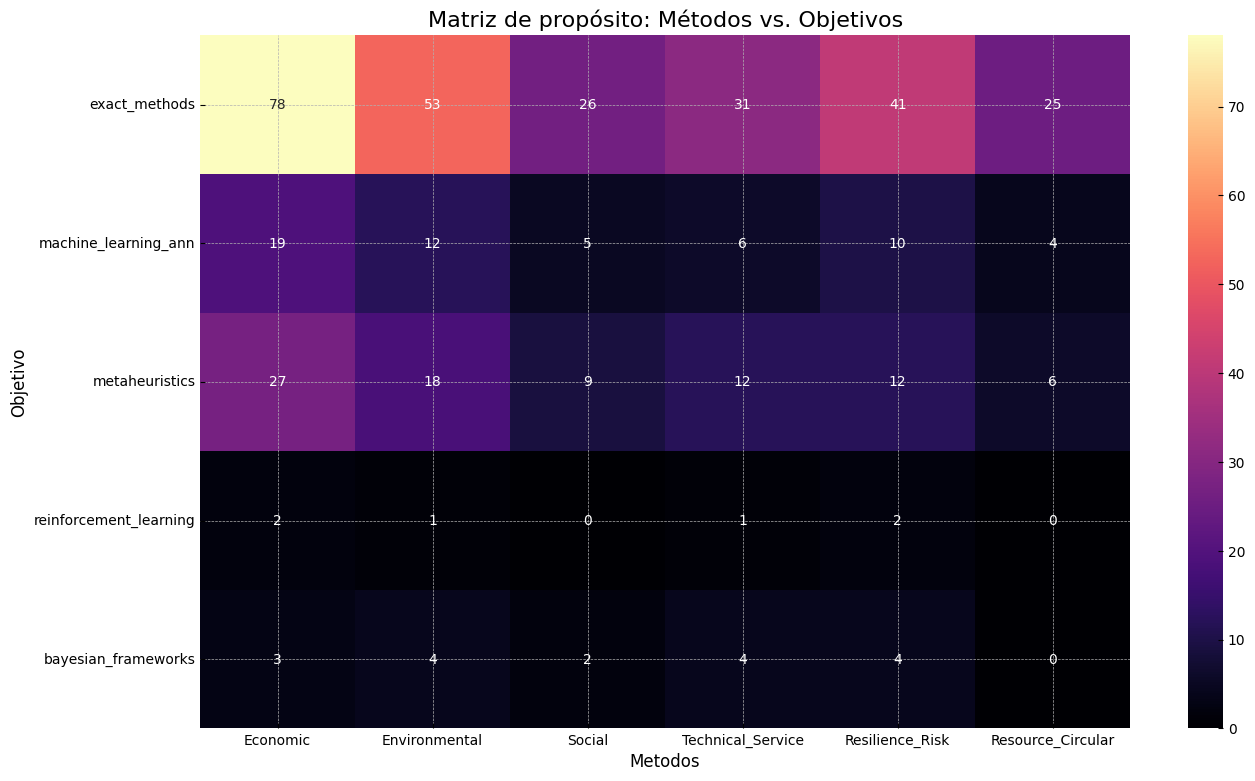

In [72]:
plt.figure(figsize=(15, 9))
sns.heatmap(m10, annot=True, fmt="d", cmap="magma")
plt.title("Matriz de propósito: Métodos vs. Objetivos", fontsize=16)
plt.xlabel("Metodos")
plt.ylabel("Objetivo")
plt.show()

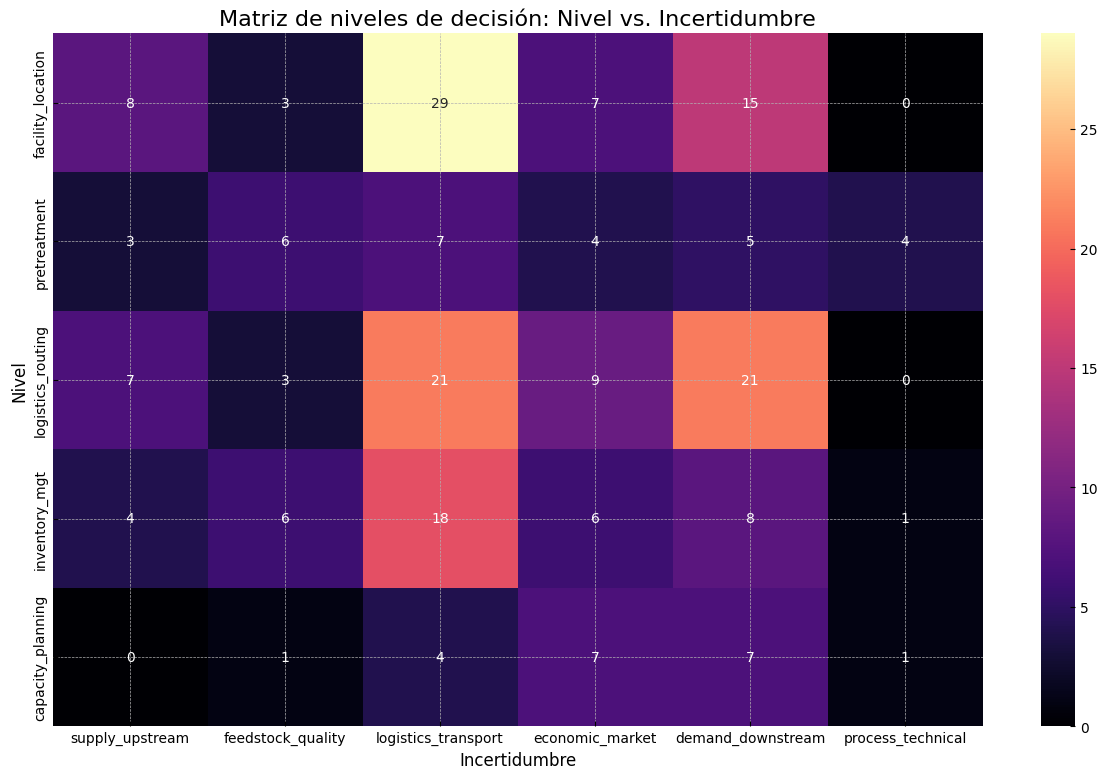

In [101]:

plt.figure(figsize=(15, 9))
sns.heatmap(m11, annot=True, fmt="d", cmap="magma")
plt.title("Matriz de niveles de decisión: Nivel vs. Incertidumbre", fontsize=16)
plt.xlabel("Incertidumbre")
plt.ylabel("Nivel")
plt.show()

In [73]:
from IPython.display import display, HTML

# 1. Definimos una lista con tus matrices y sus nombres para hacerlo en un solo loop
matrices_lista = [
    (m1, "Tabla 1: Aplicaciones vs. Métodos"),
    (m2, "Tabla 2: Incertidumbre vs. Modelos"),
    (m3, "Tabla 3: Aplicaciones vs. Sostenibilidad"),
    (m4, "Tabla 4: Modelos vs. Escala"),
    (m5, "Tabla 5: Incertidumbre vs. Sostenibilidad"),
    (m6, "Tabla 6: Métodos vs. Escala"),
    (m7, "Tabla 7: Incertidumbre vs. Modelos (Validación)"),
    (m8, "Tabla 8: IA Vanguardia vs. Aplicaciones"),
    (m9, "Tabla 9: IA Vanguardia vs. Incertidumbre"),
    (m10, "Tabla 10: Métodos vs. Objetivos")
]

# 2. Loop de visualización corregido
for matriz, titulo in matrices_lista:
    # Mostramos el título con formato HTML para que resalte
    display(HTML(f"<h3 style='color: #2e7d32; font-family: sans-serif;'>{titulo}</h3>"))

    # Mostramos la matriz (DataFrame) con el formato de tabla interactiva
    display(matriz)

    # Línea divisoria para separar los resultados
    print("\n" + "="*60 + "\n")

,exact_methods,machine_learning_ann,metaheuristics,reinforcement_learning,bayesian_frameworks
strategic_network_design,49,8,12,0,1
logistics_transportation,43,7,12,1,2
biorefinery_conversion,14,1,5,0,1
inventory_storage,2,1,0,0,0
harvesting_collection,8,0,1,0,1
market_economic_analysis,6,4,4,1,1


,stochastic_programming,robust_optimization,multiobjective_optimization,simulation_based
supply_upstream,7,5,1,3
feedstock_quality,4,1,0,3
logistics_transport,14,11,4,5
economic_market,3,2,3,6
demand_downstream,5,7,6,9
process_technical,0,0,0,2


,environmental,economic,social
strategic_network_design,38,25,6
logistics_transportation,56,33,4
biorefinery_conversion,26,14,0
inventory_storage,2,3,0
harvesting_collection,7,4,0
market_economic_analysis,23,13,0


,spatial,temporal
stochastic_programming,1,11
robust_optimization,0,11
multiobjective_optimization,0,4
simulation_based,2,7


,environmental,economic,social
supply_upstream,9,6,2
feedstock_quality,1,4,0
logistics_transport,19,10,1
economic_market,13,9,1
demand_downstream,17,9,0
process_technical,2,1,0


,spatial,temporal
exact_methods,5,13
machine_learning_ann,0,3
metaheuristics,0,5
reinforcement_learning,0,0
bayesian_frameworks,0,0


,stochastic_programming,robust_optimization,multiobjective_optimization,simulation_based
supply_upstream,7,5,1,3
feedstock_quality,4,1,0,3
logistics_transport,14,11,4,5
economic_market,3,2,3,6
demand_downstream,5,7,6,9
process_technical,0,0,0,2


,strategic_network_design,logistics_transportation,biorefinery_conversion,inventory_storage,harvesting_collection,market_economic_analysis
Machine_Learning_Classic,1,2,2,0,0,1
Deep_Learning_Architectures,3,4,1,1,0,2
Reinforcement_Learning,2,4,2,0,0,1
Physics_Informed_AI,0,0,0,0,0,0
Explainable_AI_XAI,1,1,2,0,0,1
Generative_AI_LLM,0,0,0,0,0,0
IA_Integrated_Optimization,0,0,1,0,0,0


,supply_upstream,feedstock_quality,logistics_transport,economic_market,demand_downstream,process_technical
Machine_Learning_Classic,0,0,1,1,2,0
Deep_Learning_Architectures,0,0,3,4,2,0
Reinforcement_Learning,1,1,2,1,2,0
Physics_Informed_AI,0,0,0,0,0,0
Explainable_AI_XAI,0,0,1,2,1,0
Generative_AI_LLM,0,0,0,0,0,0
IA_Integrated_Optimization,0,0,0,0,0,0


,Economic,Environmental,Social,Technical_Service,Resilience_Risk,Resource_Circular
exact_methods,78,53,26,31,41,25
machine_learning_ann,19,12,5,6,10,4
metaheuristics,27,18,9,12,12,6
reinforcement_learning,2,1,0,1,2,0
bayesian_frameworks,3,4,2,4,4,0


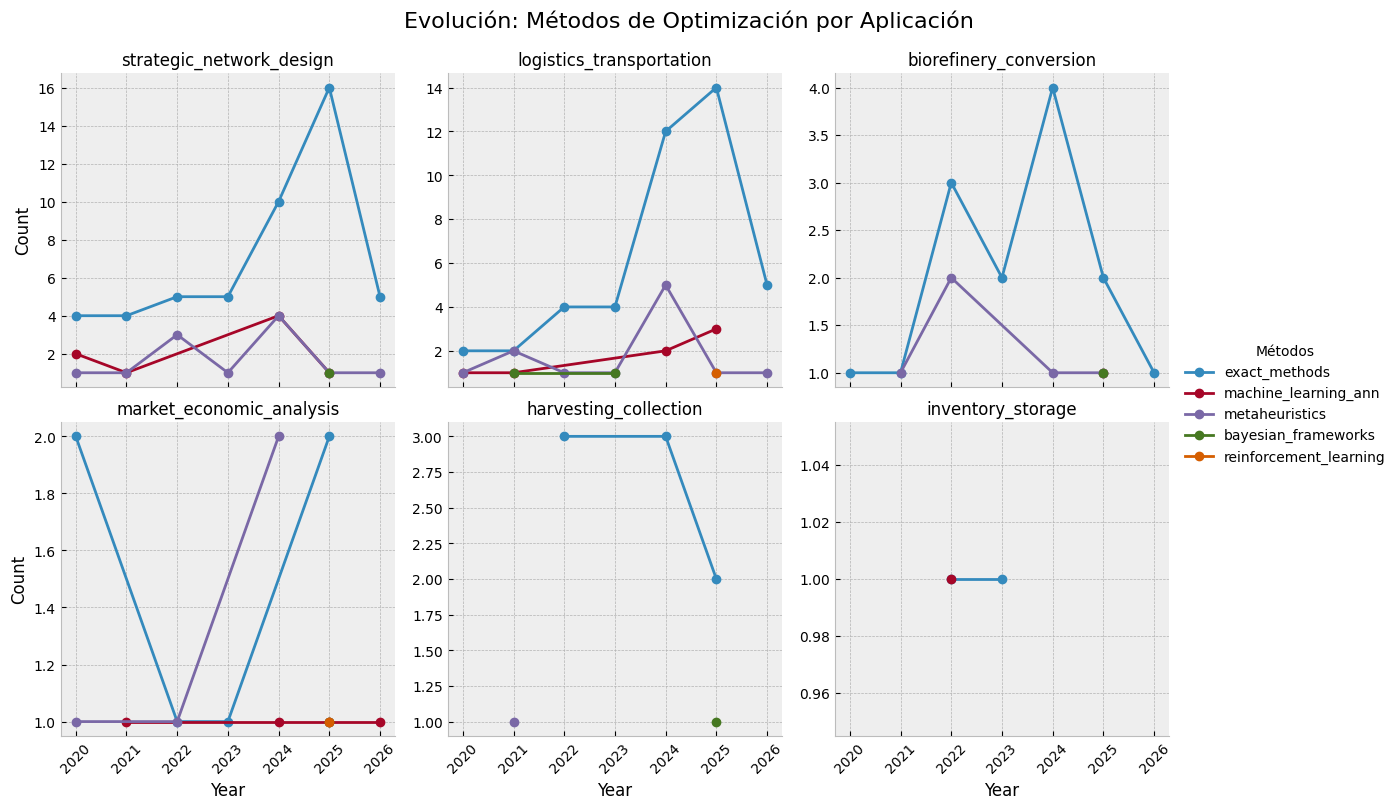

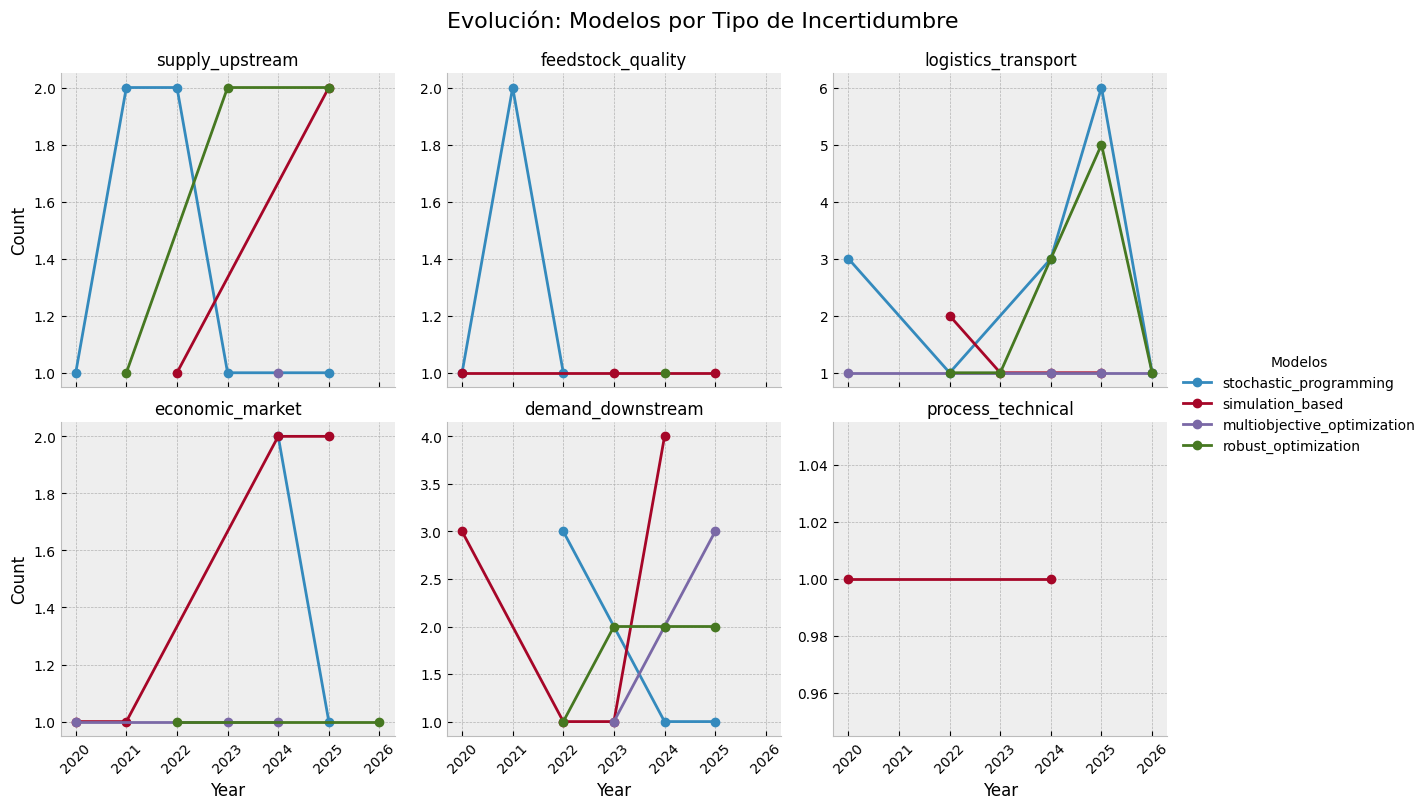

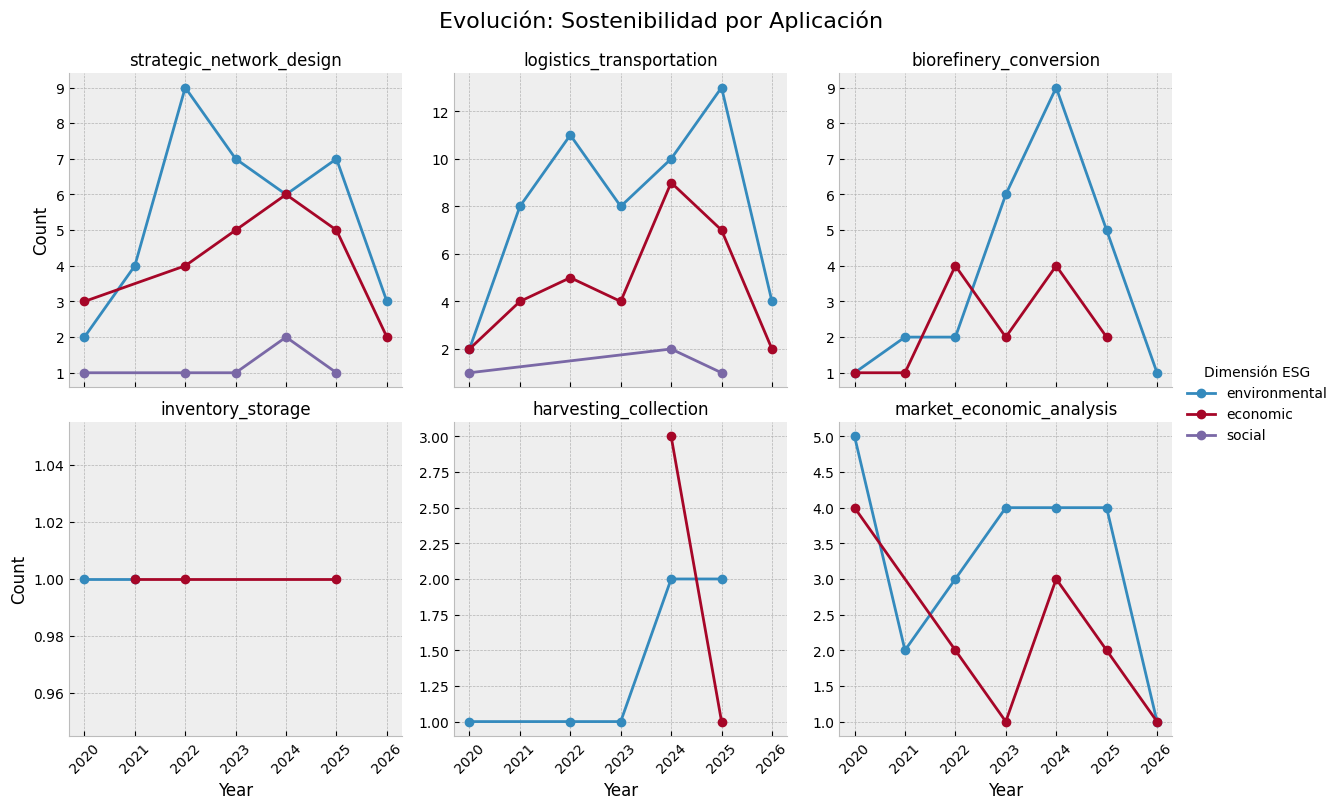

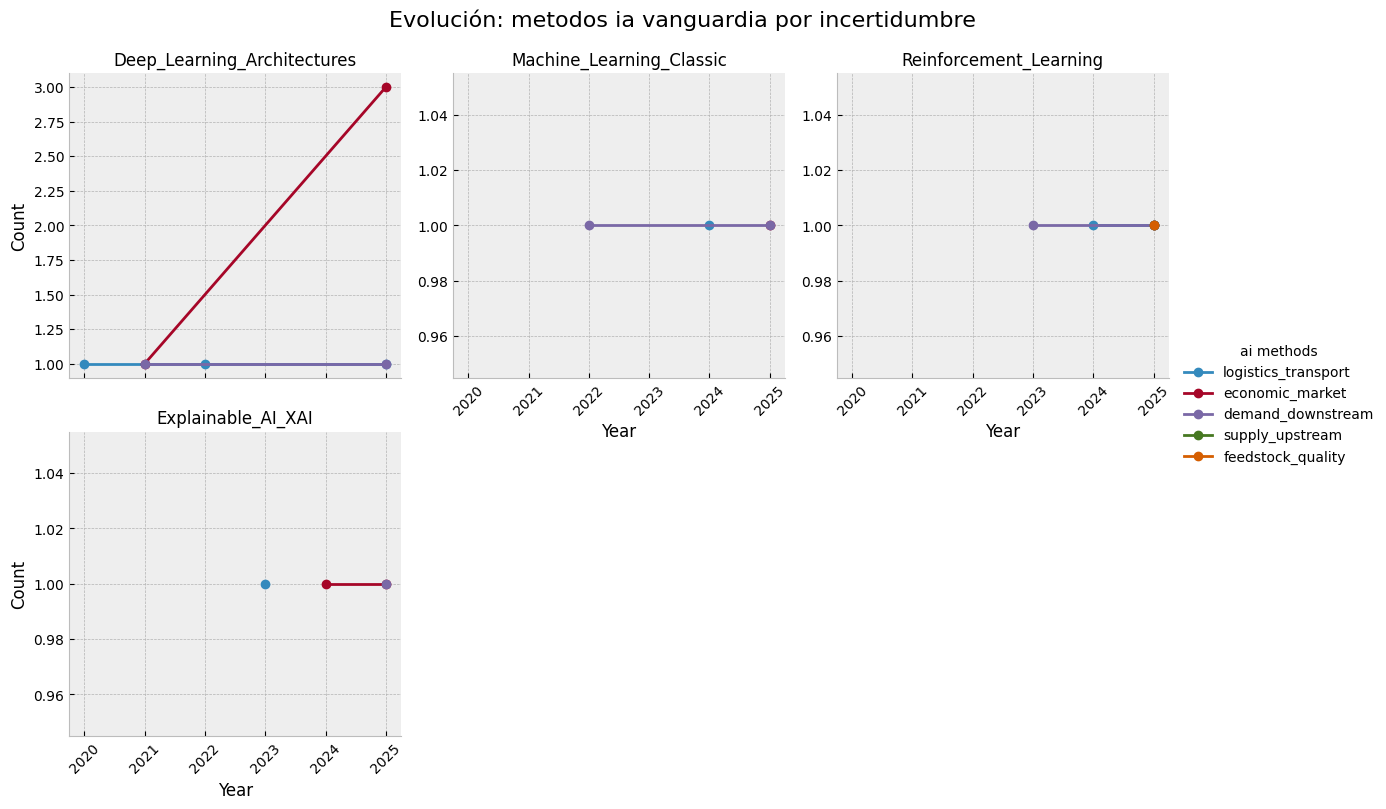

In [88]:
# 2. Procesamiento de la base de datos completa
df_final = bibfile.data.copy()

# Diccionario maestro para el loop
all_dicts = {
    "Models": optimization_models,
    "Methods": categories_methods,
    "Uncertainty": uncertainty_categories,
    "Applications": applications,
    "Sustainability": sustainability,
    "Scale": scale,
    "ai_methods_vanguardia": ai_methods_vanguardia,
    "objective_dict": objective_dict
}

# Aplicamos la búsqueda avanzada
for col_name, d_dict in all_dicts.items():
    df_final[col_name] = df_final.apply(lambda row: check_presence_pro(row, d_dict), axis=1)

# Preparación temporal
df_final['year'] = pd.to_numeric(df_final['year'], errors='coerce')
df_temporal = df_final[df_final['year'] >= 2020].dropna(subset=['year'])
df_temporal['year'] = df_temporal['year'].astype(int)

# 3. Función de procesamiento para Series Temporales
def get_timeseries_data_v2(df, col_main, col_sub, dict_main, dict_sub):
    time_data = []
    years = sorted(df['year'].unique())

    for year in years:
        df_year = df[df['year'] == year]
        for cat in dict_main.keys():
            # Filtramos artículos que pertenecen a la categoría principal
            df_cat = df_year[df_year[col_main].apply(lambda x: cat in x)]

            if not df_cat.empty:
                counts = {sub: 0 for sub in dict_sub.keys()}
                for _, row in df_cat.iterrows():
                    for sub in row[col_sub]:
                        if sub in counts: counts[sub] += 1

                for sub, count in counts.items():
                    if count > 0:
                        time_data.append({'Year': year, 'Category': cat, 'Subcategory': sub, 'Count': count})
    return pd.DataFrame(time_data)

# 4. Generación de datos para los 4 análisis
ts1 = get_timeseries_data_v2(df_temporal, "Applications", "Methods", applications, categories_methods)
ts2 = get_timeseries_data_v2(df_temporal, "Uncertainty", "Models", uncertainty_categories, optimization_models)
ts3 = get_timeseries_data_v2(df_temporal, "Applications", "Sustainability", applications, sustainability)
ts4 = get_timeseries_data_v2(df_temporal, "ai_methods_vanguardia", "Uncertainty", ai_methods_vanguardia, uncertainty_categories )

# 5. Visualización de Tendencias (Matriz 1: Apps vs Methods)
def plot_trends(df, title, hue_label):
    if df.empty:
        print(f"Sin datos para: {title}")
        return
    g = sns.FacetGrid(df, col="Category", hue="Subcategory", col_wrap=3, height=4, sharey=False)
    g.map(plt.plot, "Year", "Count", marker="o", linewidth=2)
    g.add_legend(title=hue_label)
    g.set_titles("{col_name}")
    for ax in g.axes.flat:
        ax.set_xticks(df['Year'].unique())
        ax.set_xticklabels(df['Year'].unique(), rotation=45)
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(title, fontsize=16)
    plt.show()

plot_trends(ts1, 'Evolución: Métodos de Optimización por Aplicación', 'Métodos')
plot_trends(ts2, 'Evolución: Modelos por Tipo de Incertidumbre', 'Modelos')
plot_trends(ts3, 'Evolución: Sostenibilidad por Aplicación', 'Dimensión ESG')
plot_trends(ts4, 'Evolución: metodos ia vanguardia por incertidumbre', 'ai methods')

# **Segundo hallazgo: Método vs objetivo buscado**

In [92]:
def obtener_etiqueta_principal(lista):
    """Extrae la primera etiqueta detectada o marca como 'Not Specified'"""
    if isinstance(lista, list) and len(lista) > 0:
        return lista[0]
    return "Not Specified"

# 1. Creamos la base de la tabla tomando las columnas detectadas en df_final
# Asegúrate de que estos nombres coincidan con los que usamos en la detección pro
df_matrix_completa = pd.DataFrame()

df_matrix_completa['method'] = df_final['Methods'].apply(obtener_etiqueta_principal)
df_matrix_completa['uncertainty'] = df_final['Uncertainty'].apply(obtener_etiqueta_principal)
df_matrix_completa['application'] = df_final['Applications'].apply(obtener_etiqueta_principal)
df_matrix_completa['objective'] = df_final['objective_dict'].apply(obtener_etiqueta_principal)

# 2. Limpieza final de nulos (por si quedaron celdas vacías)
df_matrix_completa = df_matrix_completa.fillna('Not Specified')
df_matrix_completa['objective'] = df_matrix_completa['objective'].replace('objective_not_stated', 'Not Specified')

# 3. Visualización de los resultados
print(f"Total de registros procesados: {len(df_matrix_completa)}")
display(df_matrix_completa.head(10)) # Primeras 10 filas
display(df_matrix_completa.tail(5))  # Últimas 5 filas como en tu imagen

Total de registros procesados: 400


,method,uncertainty,application,objective
0,exact_methods,Not Specified,strategic_network_design,Economic
1,Not Specified,Not Specified,strategic_network_design,Economic
2,Not Specified,Not Specified,Not Specified,Environmental
3,exact_methods,Not Specified,strategic_network_design,Economic
4,Not Specified,logistics_transport,Not Specified,Social
5,machine_learning_ann,demand_downstream,strategic_network_design,Economic
6,Not Specified,economic_market,logistics_transportation,Economic
7,Not Specified,Not Specified,logistics_transportation,Economic
8,exact_methods,Not Specified,Not Specified,Economic
9,Not Specified,Not Specified,Not Specified,Resilience_Risk


,method,uncertainty,application,objective
395,Not Specified,feedstock_quality,biorefinery_conversion,Resilience_Risk
396,Not Specified,Not Specified,biorefinery_conversion,Economic
397,Not Specified,feedstock_quality,biorefinery_conversion,Economic
398,exact_methods,Not Specified,strategic_network_design,Economic
399,Not Specified,supply_upstream,Not Specified,Environmental


In [102]:
!pip install networkx
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.7 MB/s eta 0:00:00


In [103]:
import networkx as nx


In [104]:
G = nx.Graph()

for _, row in df_matrix_completa.iterrows():

    method = row["method"]
    uncertainty = row["uncertainty"]
    application = row["application"]

    G.add_edge(method, uncertainty)
    G.add_edge(uncertainty, application)

In [105]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 16
Edges: 54


In [106]:
node_colors = []

for node in G.nodes():

    if node in optimization_models:
        node_colors.append("red")

    elif node in uncertainty_categories:
        node_colors.append("blue")

    else:
        node_colors.append("green")

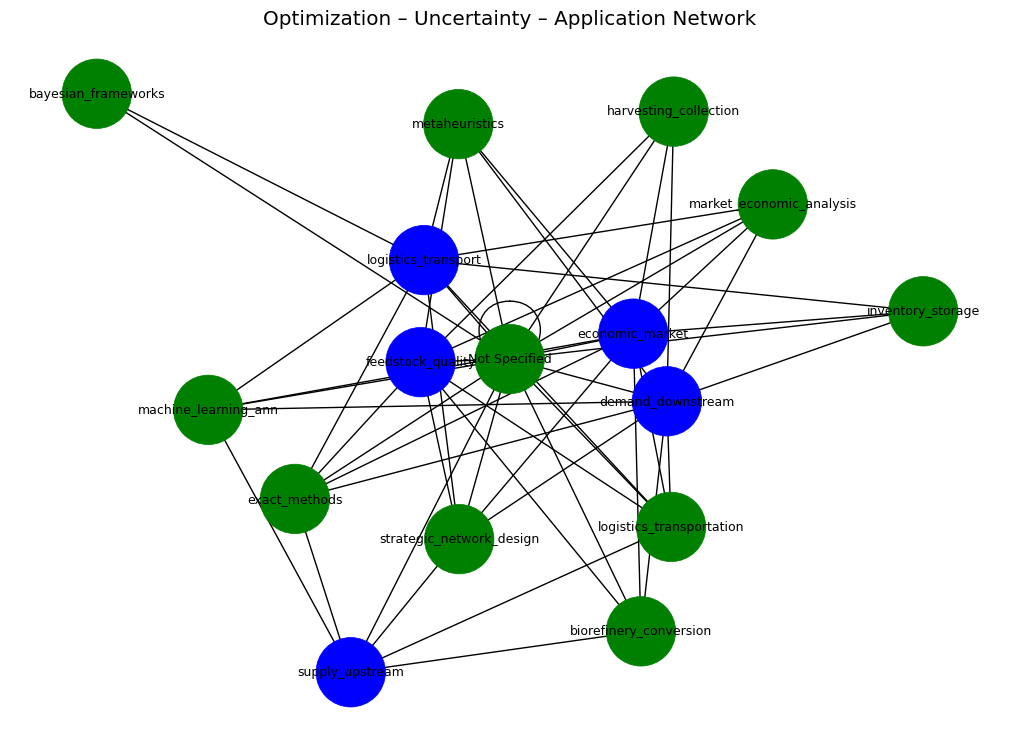

In [108]:
plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, k=0.6)

nx.draw(
    G,
    pos,
    node_color=node_colors,
    node_size=2500,
    with_labels=True,
    font_size=9
)

plt.title("Optimization – Uncertainty – Application Network")

plt.show()

In [174]:
centrality = nx.degree_centrality(G)

sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('policy_environmental', 0.625),
 ('logistics_transport', 0.625),
 ('economic_market', 0.5625),
 ('supply_upstream', 0.5625),
 ('demand_downstream', 0.5),
 ('biorefinery_conversion', 0.4375),
 ('simulation_based', 0.4375),
 ('stochastic_programming', 0.375),
 ('logistics_transportation', 0.375),
 ('market_economic_analysis', 0.375)]

In [175]:
print(df_matrix_completa[['method', 'uncertainty', 'application']].isnull().sum())

method         0
uncertainty    0
application    0
dtype: int64


In [176]:
print(len(df_matrix_completa))

449
